# Model 1 - Fixed service batch sizes, $b_I=1$ (detailed diagrams)

## Load libraries

In [10]:
import matplotlib.pyplot as plt

import libs.tools as tools
import libs.QueueApprox as QueueApprox

plt.style.use('seaborn-v0_8')

## Load and process data

In [11]:
# Number of operators needed in bS=1 case
c_needed = 16

data = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["bI"] == 1)
tools.load_statistics(data)

### Calculate E[W] increasement relative to b=1 case

In [12]:
for rec in data:
    if rec["b_max"] == 1:
        rec["E[W]rel"] = 1
    else:
        base = tools.find_same_with_other_b(data, rec, None, 1, 1, None)
        rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

### Calculate maximum relative error between simulation and approximation

#### Without KLB

In [13]:
rel_delta_max = 0
rel_delta_max_rec = None
rel_delta_max_EW = 0
rel_delta_max_EW_approx = 0
for rec in data:
    rho = rec["model_rho"]
    EW = rec["E[W]"]
    EW_approx = QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], rec["c"], 1, rec["b_max"])
    rel_delta = abs(EW - EW_approx) / EW if EW != 0 else 0
    if rel_delta > rel_delta_max:
        rel_delta_max = rel_delta
        rel_delta_max_rec = rec
        rel_delta_max_EW = EW
        rel_delta_max_EW_approx = EW_approx

print(f"Max relative delta: {rel_delta_max*100:.4f}%")
if rel_delta_max_rec is not None:
    print(f"Record with max relative delta: {rel_delta_max_rec['name_short']}")
    print("E[W]=",rel_delta_max_EW)
    print("E[W]_approx=",rel_delta_max_EW_approx)

Max relative delta: 42.6546%
Record with max relative delta: S=Log, CV[S]=1.5, rho=60%, bI=1, bS=1
E[W]= 7.15371675301092
E[W]_approx= 10.205109085754486


#### With KLB

In [14]:
rel_delta_max = 0
rel_delta_max_rec = None
rel_delta_max_EW = 0
rel_delta_max_EW_approx = 0
for rec in data:
    rho = rec["model_rho"]
    EW = rec["E[W]"]
    EW_approx = QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], rec["c"], 1, rec["b_max"], True)
    rel_delta = abs(EW - EW_approx) / EW if EW != 0 else 0
    if rel_delta > rel_delta_max:
        rel_delta_max = rel_delta
        rel_delta_max_rec = rec
        rel_delta_max_EW = EW
        rel_delta_max_EW_approx = EW_approx

print(f"Max relative delta: {rel_delta_max*100:.4f}%")
if rel_delta_max_rec is not None:
    print(f"Record with max relative delta: {rel_delta_max_rec['name_short']}")
    print("E[W]=",rel_delta_max_EW)
    print("E[W]_approx=",rel_delta_max_EW_approx)

Max relative delta: 42.6546%
Record with max relative delta: S=Log, CV[S]=1.5, rho=60%, bI=1, bS=1
E[W]= 7.15371675301092
E[W]_approx= 10.205109085754486


## Plot results

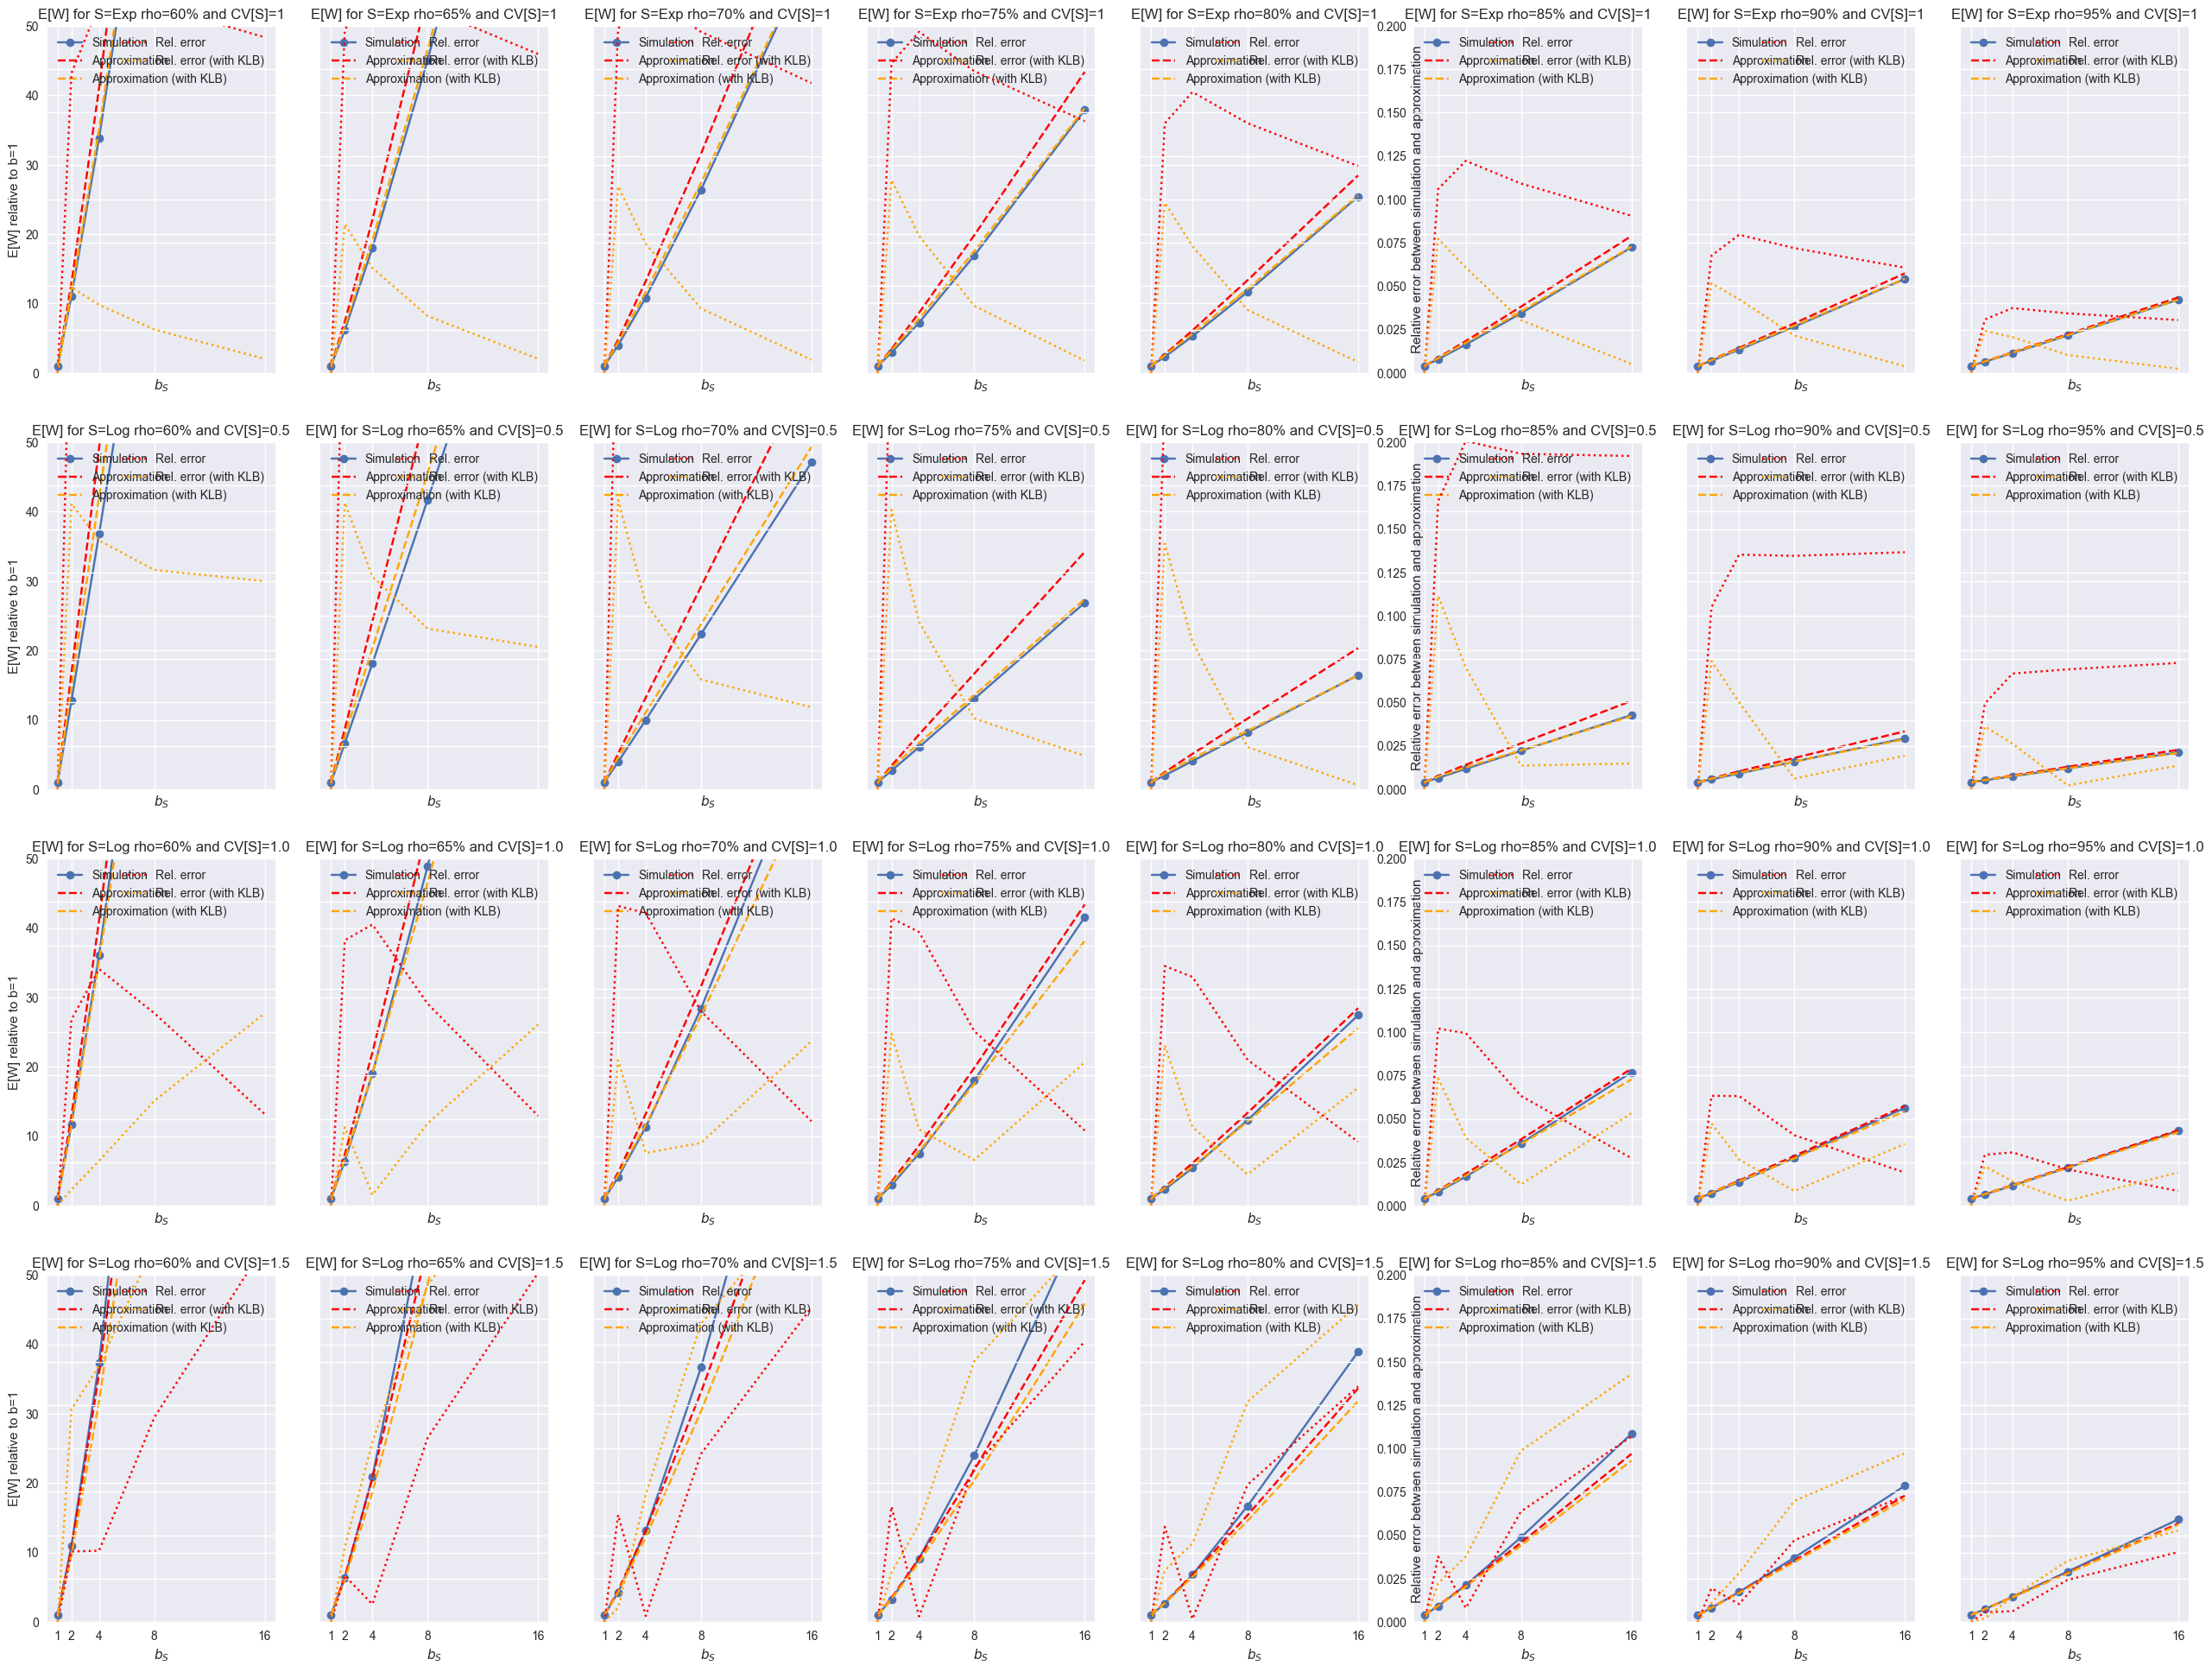

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        plot_approx1_data = []
        plot_approx2_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_max"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]rel"]})
            plot_approx1_data.append({"b": b, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], rec["c"], 1, rec["b_max"]) / QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], c_needed, 1, 1)})
            plot_approx2_data.append({"b": b, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], rec["c"], 1, rec["b_max"], True) / QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], c_needed, 1, 1, True)})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])
        plot_approx1_data = sorted(plot_approx1_data, key=lambda rec: rec["b"])
        plot_approx2_data = sorted(plot_approx2_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]
        y_approx1 = [rec["E[W]"] for rec in plot_approx1_data]
        y_approx2 = [rec["E[W]"] for rec in plot_approx2_data]
        y_delta1 = [abs(y_sim[i] - y_approx1[i]) / y_sim[i] for i in range(len(plot_sim_data))]
        y_delta2 = [abs(y_sim[i] - y_approx2[i]) / y_sim[i] for i in range(len(plot_sim_data))]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.plot(x, y_approx1, linestyle='--', color='red', label="Approximation")
        ax1.plot(x, y_approx2, linestyle='--', color='orange', label="Approximation (with KLB)")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] relative to b=1")
        ax1.set_ylim(0, 50)

        ax2 = ax1.twinx()
        ax2.plot(x, y_delta1, linestyle=':', color='red', label="Rel. error")
        ax2.plot(x, y_delta2, linestyle=':', color='orange', label="Rel. error (with KLB)")
        if j == 4:
            ax2.set_ylabel("Relative error between simulation and approximation")
        ax2.set_ylim(0, 0.2)
        if j != 4:
            ax2.set_yticklabels(labels=[])

        ax1.set_xlabel("$b_S$")
        ax2.set_xlabel("$b_S$")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")
        ax1.legend(loc=2)
        ax2.legend(loc=1)

# fig.savefig("images/Model01-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

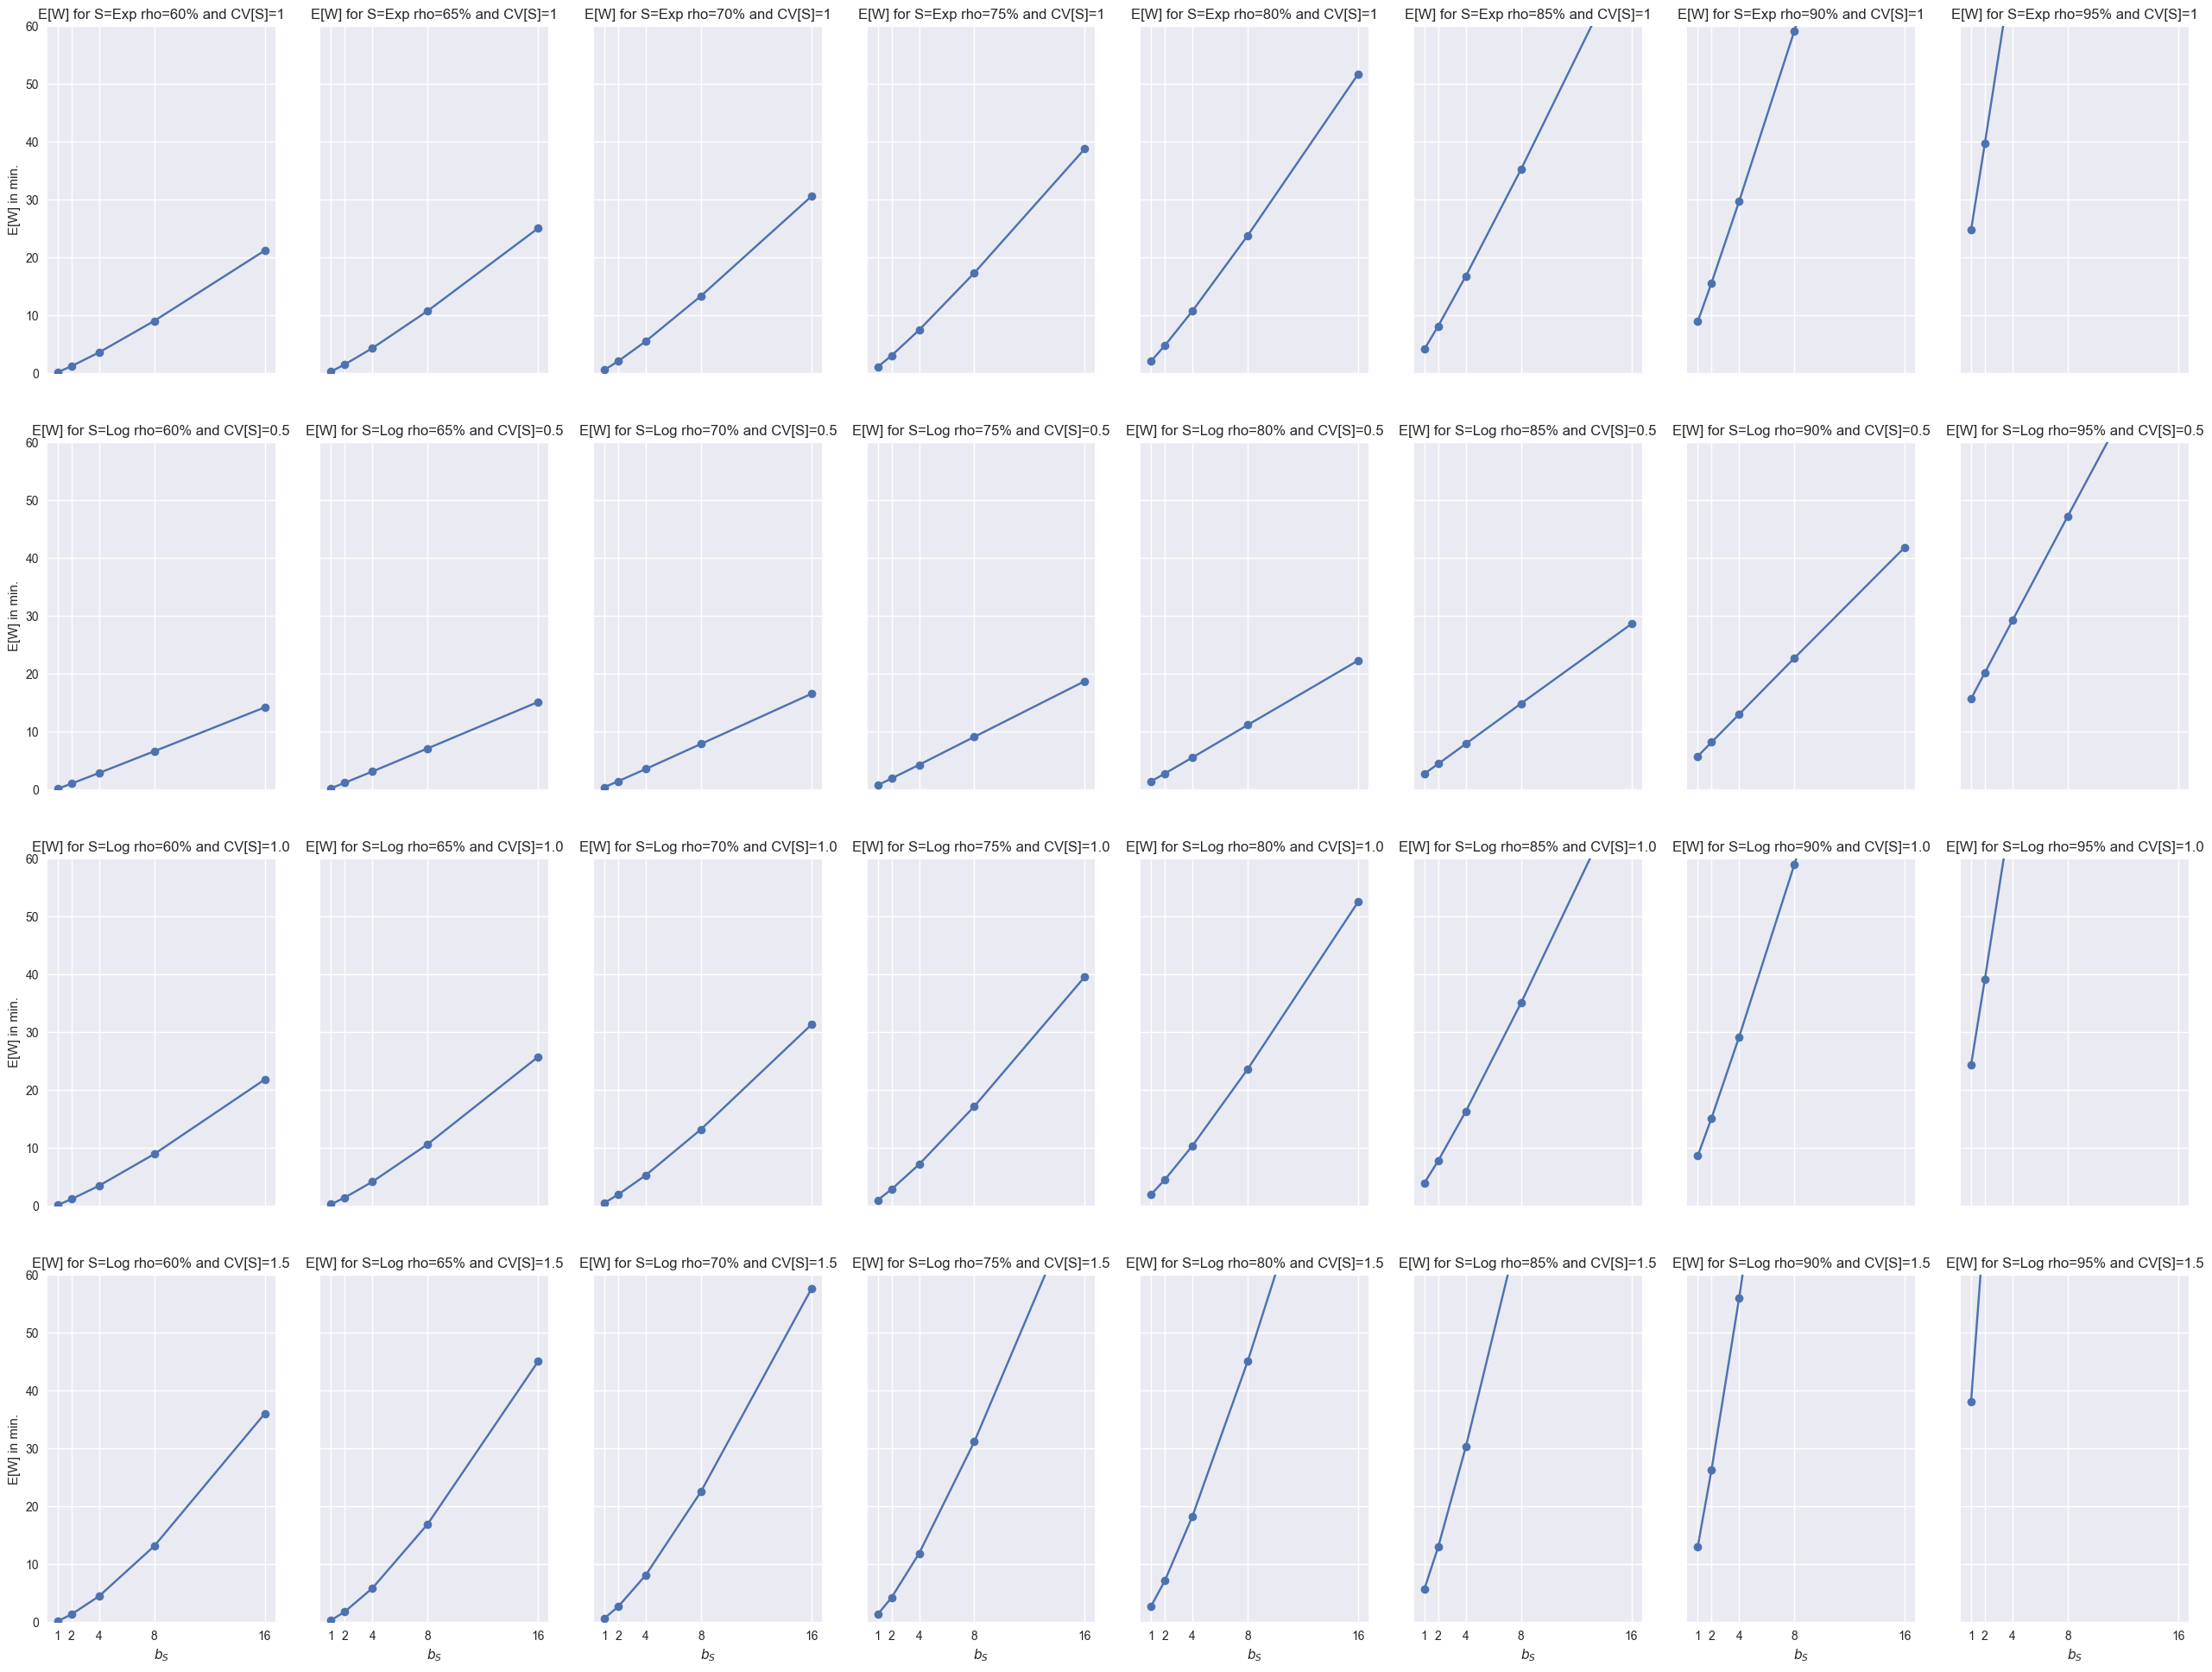

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.6 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_max"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]"]/60})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] in min.")
        ax1.set_ylim(0, 60)
        if i == 3:
            ax1.set_xlabel("$b_S$")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model01-EW-details.png", format="png", bbox_inches='tight', pad_inches=0)

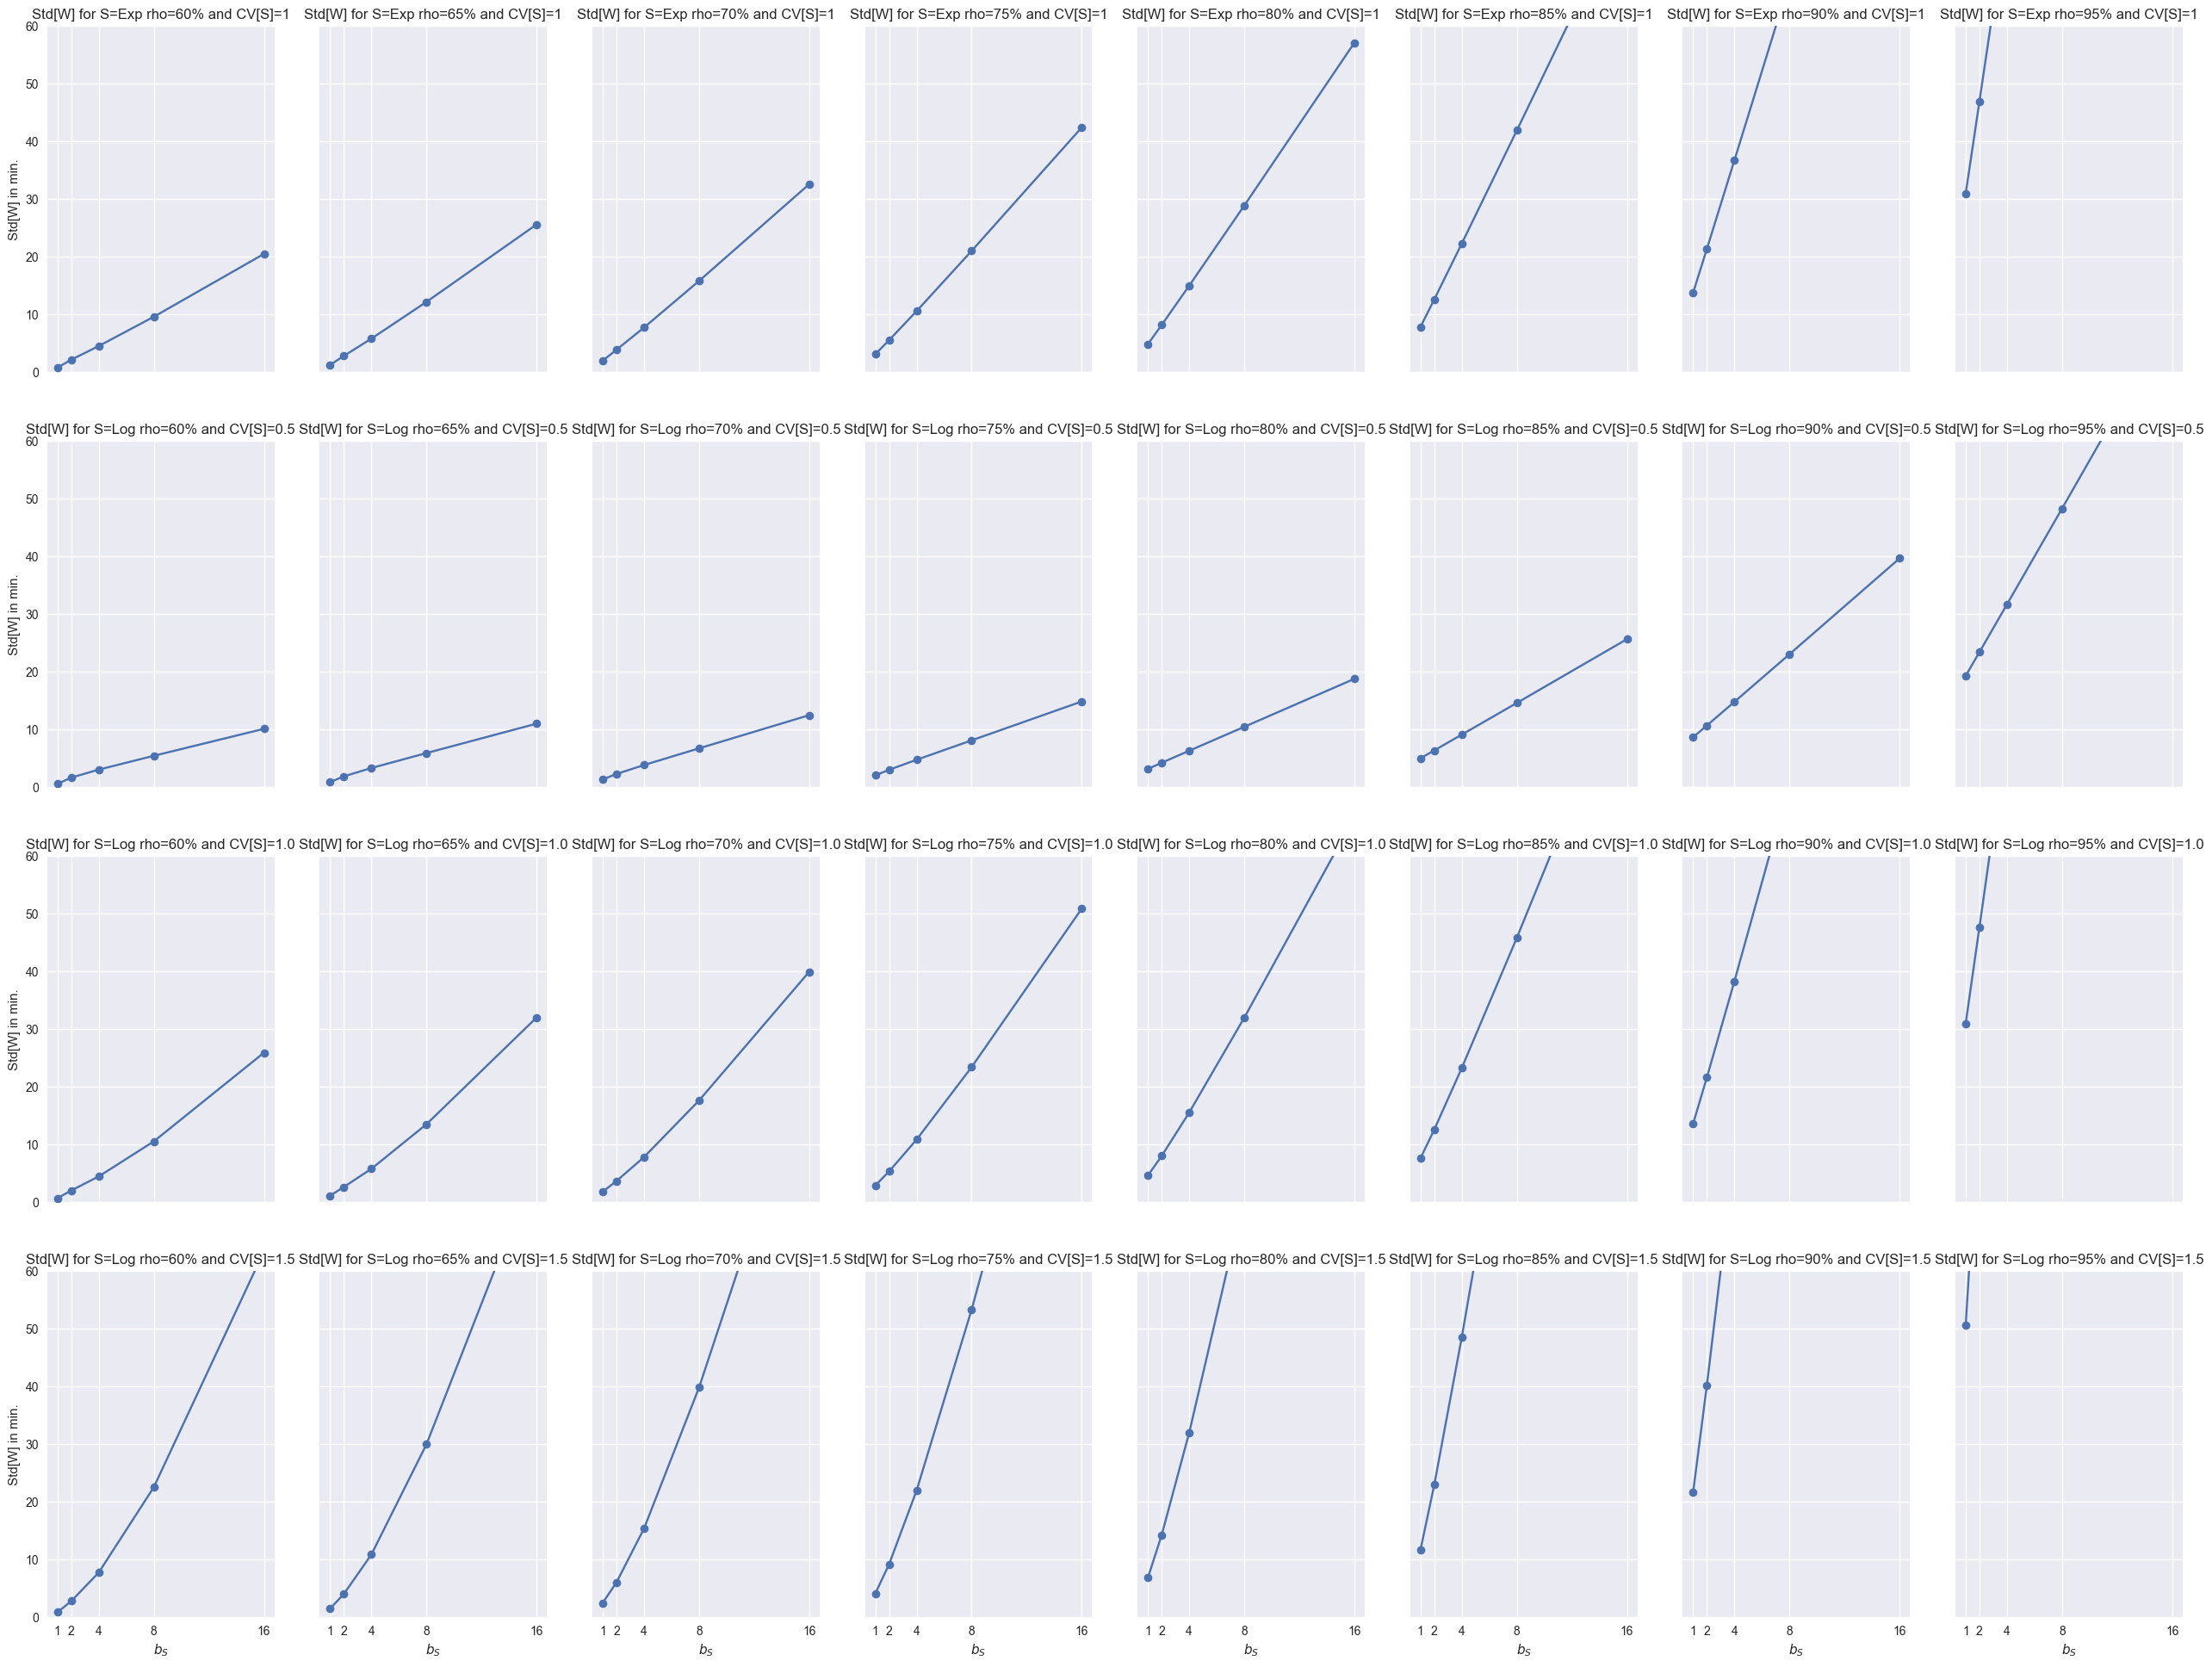

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.6 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_max"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "Std[W]": rec["Std[W]"] / 60})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["Std[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("Std[W] in min.")
        ax1.set_ylim(0, 60)
        if i == 3:
            ax1.set_xlabel("$b_S$")

        ax1.set_title(f"Std[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model01-StdW-details.png", format="png", bbox_inches='tight', pad_inches=0)

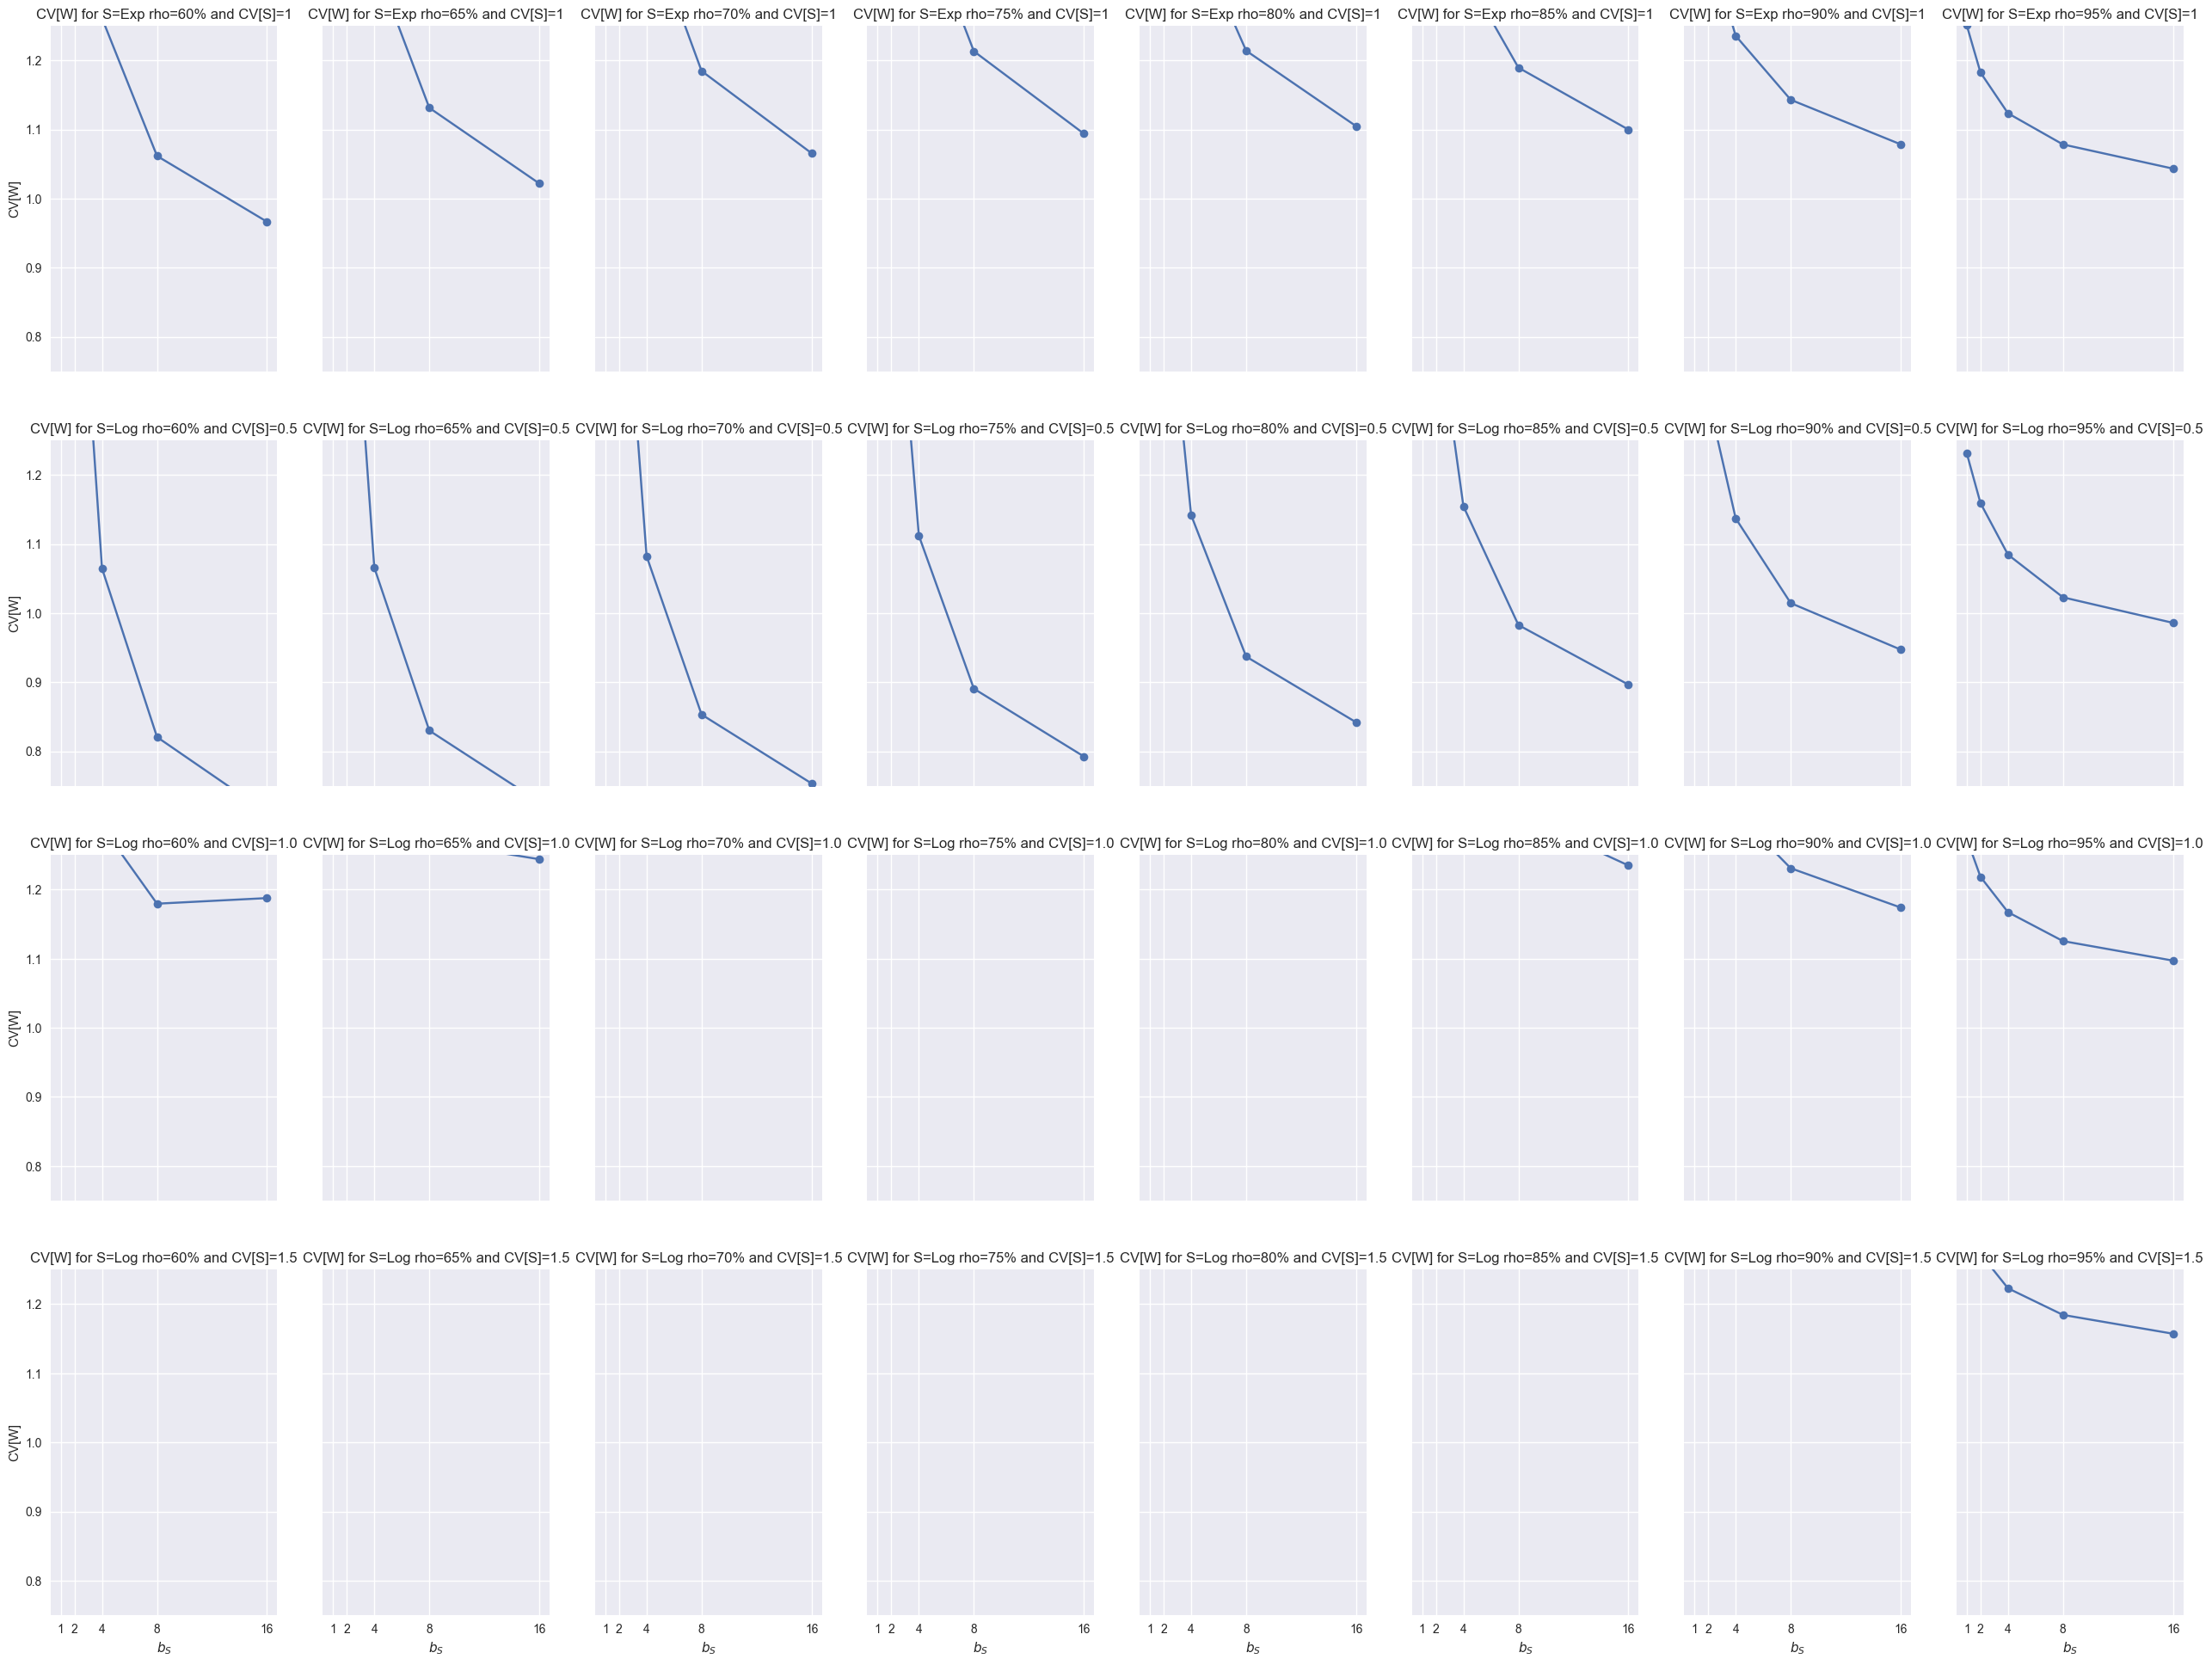

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.6 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_max"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "CV[W]": rec["CV[W]"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["CV[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("CV[W]")
        ax1.set_ylim(0.75, 1.25)
        if i == 3:
            ax1.set_xlabel("$b_S$")

        ax1.set_title(f"CV[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model01-CVW-details.png", format="png", bbox_inches='tight', pad_inches=0)